In [173]:
import subprocess

from glob import glob
import os
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

rc = mpl.rcParams # Font structure is called rc now
rc['text.usetex'] = True # Tex fonts
rc['font.family'] = 'serif'
rc['font.size'] = 20
rc['xtick.labelsize'] = 15
rc['ytick.labelsize'] = 15
rc['lines.linewidth'] = 2
rc["axes.axisbelow"] = False
plt.rcParams['axes.formatter.min_exponent'] = 2
rc['axes.linewidth'] = 1.5
plt.rcParams["figure.figsize"] = (8, 6)

NUM_GHOSTS = 3

In [174]:
folder = "output"
data = {}

for filepath in sorted(glob(os.path.join(folder, "*.h5"))):
    run_name = os.path.splitext(os.path.basename(filepath))[0]
    print(f"Reading {filepath}")

    with h5py.File(filepath, "r") as f:
        data[run_name] = {
            "t": f["t"][:],
            "r": f["r"][:],
            "u": f["u"][:],
            "v": f["v"][:],
            "lapse": f["lapse"][:],
            "phi": f["phi"][:],
            "K": f["K"][:],
            "bh_mass": f["bh_mass"][:],
            "ah_radius": f["ah_radius"][:],
            "Ham": f["Ham"][:],
            "Mom": f["Mom"][:],
            "ampl": f.attrs["ampl"],
            "wid": f.attrs["wid"],
            "r0": f.attrs["r0"],
            "Omega": f.attrs["Omega"],

        }


Reading output/run_0000.h5
Reading output/run_0001.h5
Reading output/run_0002.h5
Reading output/run_0003.h5
Reading output/run_0004.h5


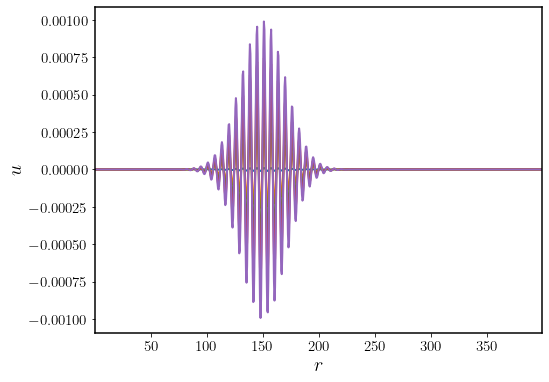

In [175]:
# Plot t_delay vs r
for run_name, run in data.items():
    plt.plot(run["r"], run["u"][0],label=r"$u=$"+" "+str(run["ampl"]))
plt.ylabel(r"$u$")
plt.xlabel(r"$r$")
plt.xlim([run["r"][NUM_GHOSTS],run["r"][-NUM_GHOSTS]])


# plt.legend(loc="best")
plt.show()

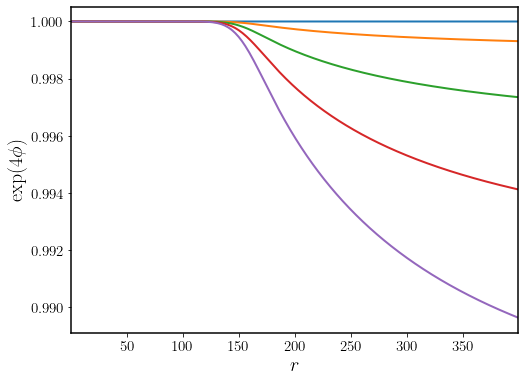

In [176]:
i = 0
# Plot rho vs r at given t
for run_name, run in data.items():
    plt.plot(run["r"], np.exp(2*run["phi"][i]),label=r"$\delta t=$"+" "+str(run["ampl"]))
plt.ylabel(r"$\exp(4\phi)$")
plt.xlabel(r"$r$")
plt.xlim([run["r"][NUM_GHOSTS],run["r"][-NUM_GHOSTS]])

# plt.legend(loc="best")
plt.show()

In [182]:
# Pick a simulation to plot

i_simulation = 4
run = data[list(data.keys())[i_simulation]]

NUM_GHOSTS = 3

t = run["t"]
r = run["r"]
u = run["u"]
v = run["v"]
phi = run["phi"]
lapse = run["lapse"]
ah_radius = run["ah_radius"]

num_points_t = len(lapse)

max_u = np.max(u)
min_u = np.min(u)

max_v = np.max(v)
min_v = np.min(v)

    
print("This run is ampl="+str(run["ampl"]))

This run is ampl=0.001


In [183]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create a figure and axes
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), facecolor="white")

# Initialize empty lines for the plots
line1, = ax1.plot([], [], color='k')
line2, = ax2.plot([], [], color='k')
line22, = ax2.plot([], [], color='r',ls="--")
line3, = ax3.plot([], [], color='k')
line4 = ax1.axvline(x=0, color='r', label="BH horizon")
line5 = ax2.axvline(x=0, color='r')
line6 = ax3.axvline(x=0, color='r')
line7 = ax1.axvline(x=0, color='b')
line8 = ax2.axvline(x=0, color='b')
line9 = ax3.axvline(x=0, color='b')

# Set labels
ax1.set_ylabel(r"$ru$",fontsize=30)
ax2.set_ylabel(r"$rv$",fontsize=30)
ax3.set_ylabel(r"$\alpha$",fontsize=30)
ax3.set_xlabel(r"$r$",fontsize=30)

ax1.set_xticklabels([])
ax2.set_xticklabels([])

# Define the initialization function
def init():
    ax1.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])
    ax2.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])
    ax3.set_xlim(r[NUM_GHOSTS], r[-NUM_GHOSTS])


    ax1.set_ylim(1.1 * min_u, 1.1 * max_u)  # Set y-limits for rho
    ax2.set_ylim(1.1*min_v, 1.1*max_v)  # Adjust as needed for vr
    ax3.set_ylim(0, 1.1)
    
    # ax1.set_title(t[i])

    return line1, line2, line3, line4, line5, line6, line7, line8, line9

# Define the update function for each frame
def update(i):

    # line1.set_data(r, rho[i])
    line1.set_data(r, r*u[i])
    line2.set_data(r, r*v[i])
    line3.set_data(r, lapse[i])

    line4.set_xdata(ah_radius[i])
    line5.set_xdata(ah_radius[i])
    line6.set_xdata(ah_radius[i])

    
    if ah_radius[i]>0:
        ax1.legend(loc="upper right")

    return line1, line2, line3, line4, line5, line6, line7, line8, line9

# Create the animatio3
ani = FuncAnimation(fig, update, frames=range(0, num_points_t, 5), init_func=init, blit=True)

# print(max_rho)
plt.close()
# Display the animation interactively.
HTML(ani.to_jshtml())

In [ ]:
from matplotlib.animation import FFMpegWriter
import matplotlib.animation as animation
import matplotlib

matplotlib.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg'  # Replace with actual path to ffmpeg

writer = FFMpegWriter(fps=10)
print("FFmpeg is ready!")

ani.save("movies/output.mp4", writer=writer)

FFmpeg is ready!


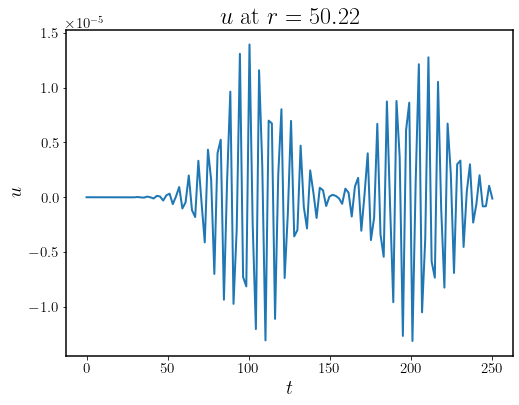

In [169]:
# Plot scalar field at r vs t
r_extract = 50
i_rext = np.argmin(np.abs(r - r_extract))   # index of closest r point

plt.plot(t, u[:, i_rext])
plt.ylabel(r"$u$")
plt.xlabel(r"$t$")
plt.title(rf"$u$ at $r = {r[i_rext]:.2f}$")
plt.show()

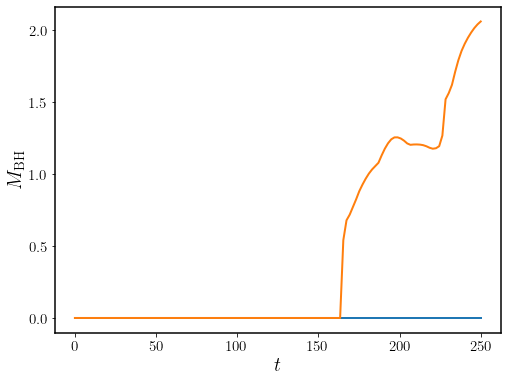

In [170]:
# Plot Mbh vs t
for run_name, run in data.items():    
    plt.plot(run["t"], run["bh_mass"], label=r"$A =$"+" "+str(run["ampl"]))

plt.ylabel(r"$M_\mathrm{BH}$")
plt.xlabel(r"$t$")

# plt.legend(loc="best")
plt.show()